# Эксперимент 3: Инфраструктурные признаки OSM

Добавляем расстояния до метро, школ, больниц и парков для Москвы, СПб, Новосибирска.

In [3]:
import os
# Navigate to project root regardless of how Jupyter was launched
for _p in [".", "..", "../.."]:
    if os.path.exists(os.path.join(_p, "data", "processed")):
        os.chdir(_p)
        break
print("Working dir:", os.getcwd())

Working dir: c:\Users\Vlad\projects\diplom__new


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

REGION_NAMES = {77: 'Москва', 78: 'Санкт-Петербург', 54: 'Новосибирск'}

In [5]:
df = pd.read_csv('data/processed/cities_3_with_infra.csv', parse_dates=['date'])
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f'Всего строк: {len(df):,}')
for r, name in REGION_NAMES.items():
    n = (df['region'] == r).sum()
    print(f'  {name} (регион {r}): {n:,}')
df.head(3)

Всего строк: 4,387,595
  Москва (регион 77): 1,503,871
  Санкт-Петербург (регион 78): 1,222,354
  Новосибирск (регион 54): 1,661,370


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,object_type,region,source,dist_to_center,dist_metro,dist_school,dist_hospital,dist_park,year,month
0,2018-03-04,4704280,1,25,1,31.7,6.0,55.621097,37.431002,1,77.0,all_v2,18.994535,0.437312,1.643022,1.398936,2.790885,2018,3
1,2018-03-17,8000000,5,9,2,45.0,6.0,55.738876,37.825370,0,77.0,all_v2,13.157806,1.532358,0.439989,0.285083,0.572836,2018,3
2,2018-04-03,11500000,14,16,3,64.9,8.0,55.798921,37.738090,0,77.0,all_v2,8.945621,0.702701,0.210879,0.676317,0.362632,2018,4


## 1. EDA новых признаков

In [6]:
infra_cols = ['dist_metro', 'dist_school', 'dist_hospital', 'dist_park']
print(df[infra_cols].describe().round(3))

        dist_metro  dist_school  dist_hospital    dist_park
count  4387595.000  4387595.000    4387595.000  4387595.000
mean         3.550        0.935          1.040        1.177
std         11.889        9.962         10.275       10.170
min          0.003        0.001          0.000        0.001
25%          0.678        0.246          0.241        0.311
50%          1.365        0.390          0.436        0.613
75%          3.288        0.679          0.765        0.989
max       3312.337     3286.160       3300.016     3288.048


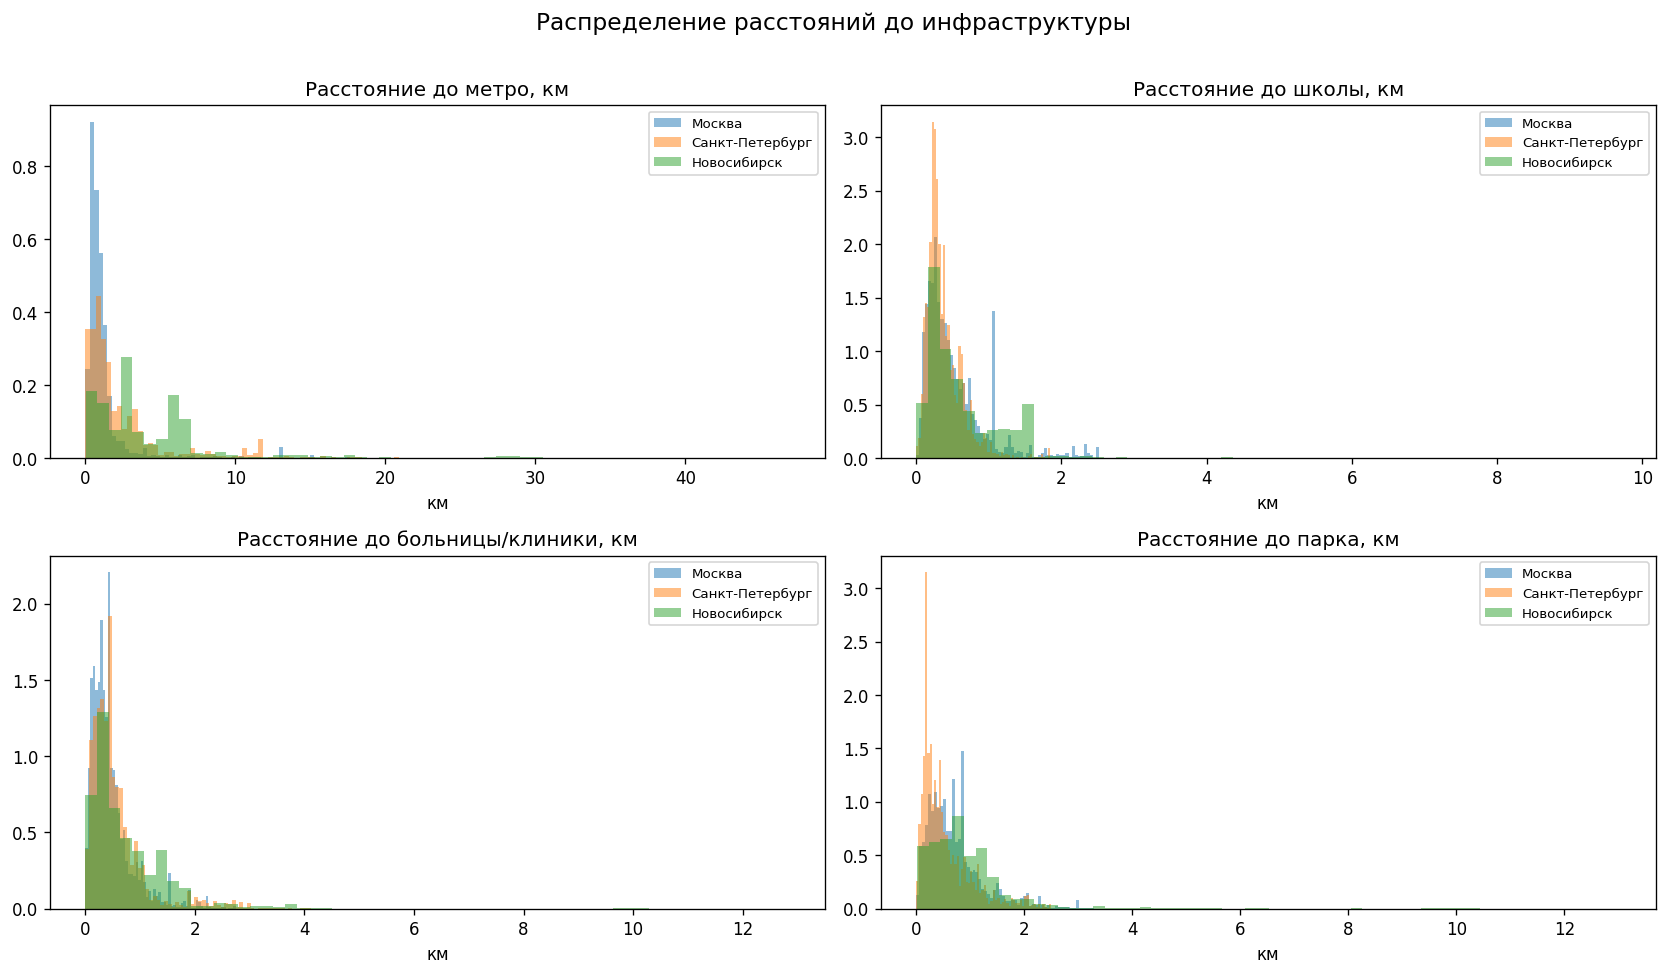

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
titles = {
    'dist_metro':    'Расстояние до метро, км',
    'dist_school':   'Расстояние до школы, км',
    'dist_hospital': 'Расстояние до больницы/клиники, км',
    'dist_park':     'Расстояние до парка, км',
}
for ax, col in zip(axes.flat, infra_cols):
    for r, name in REGION_NAMES.items():
        sub = df[df['region'] == r][col].dropna()
        cap = sub.quantile(0.99)
        sub = sub[sub <= cap]
        ax.hist(sub, bins=60, alpha=0.5, label=name, density=True)
    ax.set_title(titles[col])
    ax.set_xlabel('км')
    ax.legend(fontsize=8)
plt.suptitle('Распределение расстояний до инфраструктуры', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/exp3_infra_distributions.png', bbox_inches='tight')
plt.show()

## 2. Корреляция новых признаков с ценой

In [8]:
log_price = np.log1p(df['price'])
print('Корреляция Пирсона (log price vs расстояние):')
for c in infra_cols:
    r = log_price.corr(df[c].fillna(df[c].median()))
    print(f'  {c}: {r:.4f}')

Корреляция Пирсона (log price vs расстояние):
  dist_metro: -0.1861
  dist_school: -0.0708
  dist_hospital: -0.0776
  dist_park: -0.0762


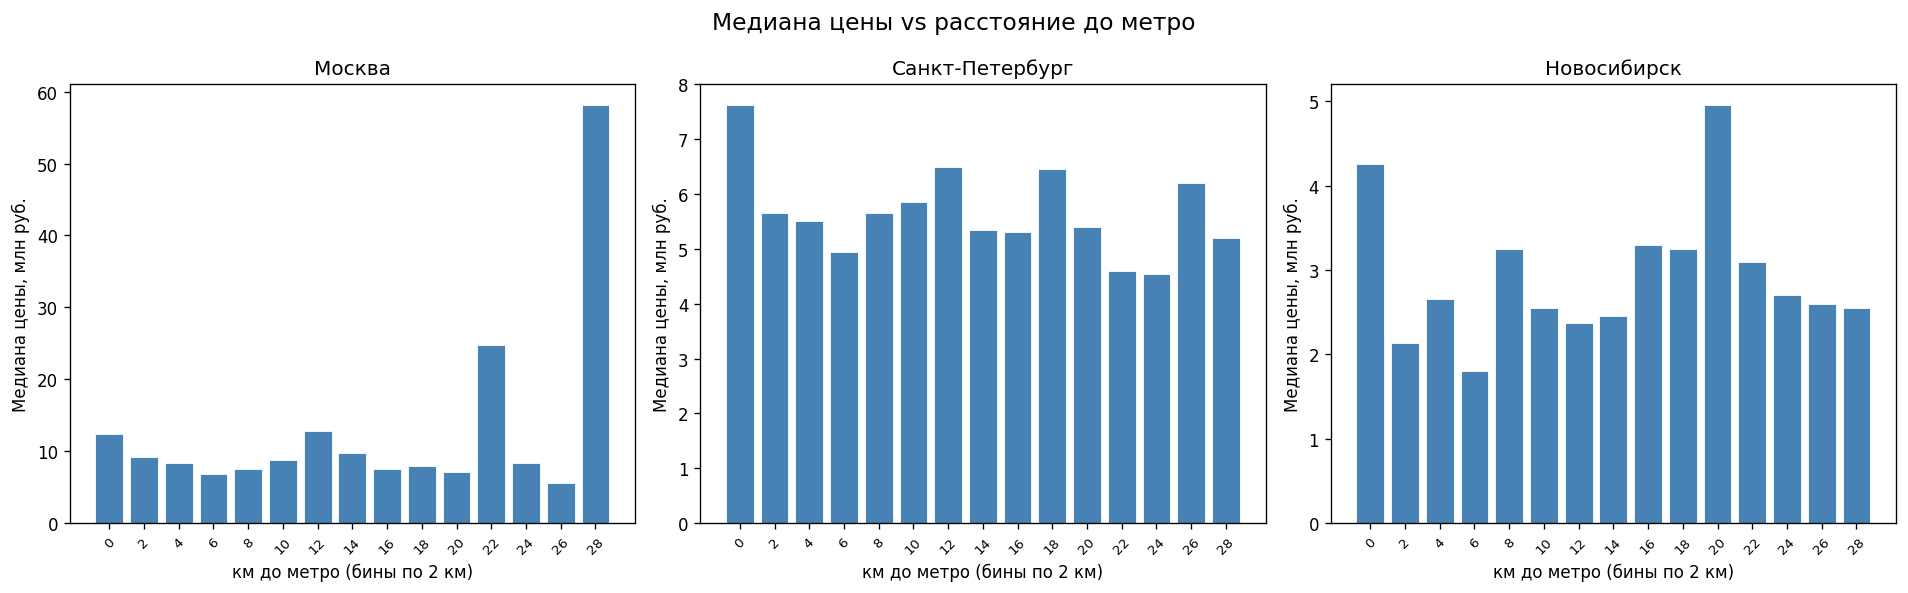

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (r, name) in zip(axes, REGION_NAMES.items()):
    sub = df[df['region'] == r].copy()
    sub = sub[sub['dist_metro'].notna() & (sub['dist_metro'] < 30)]
    sub['metro_bin'] = pd.cut(sub['dist_metro'], bins=np.arange(0, 31, 2), right=False)
    med = sub.groupby('metro_bin')['price'].median() / 1e6
    ax.bar(range(len(med)), med.values, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(med)))
    ax.set_xticklabels([str(b.left) for b in med.index], rotation=45, fontsize=8)
    ax.set_title(name)
    ax.set_xlabel('км до метро (бины по 2 км)')
    ax.set_ylabel('Медиана цены, млн руб.')
plt.suptitle('Медиана цены vs расстояние до метро', fontsize=14)
plt.tight_layout()
plt.savefig('results/figures/exp3_price_vs_metro.png', bbox_inches='tight')
plt.show()

## 3. Обучение моделей

In [10]:
FEATURES_BASE = ['level', 'levels', 'rooms', 'area', 'kitchen_area',
                 'geo_lat', 'geo_lon', 'object_type', 'region',
                 'dist_to_center', 'year', 'month']
FEATURES_INFRA = FEATURES_BASE + ['dist_metro', 'dist_school', 'dist_hospital', 'dist_park']

df_model = df.copy()
for c in ['dist_metro', 'dist_school', 'dist_hospital', 'dist_park']:
    df_model[c] = df_model[c].fillna(df_model[c].median())
df_model['kitchen_area'] = df_model['kitchen_area'].fillna(df_model['kitchen_area'].median())

train = df_model[df_model['year'] <= 2020]
test  = df_model[df_model['year'] == 2021]
print(f'Train: {len(train):,} | Test: {len(test):,}')

N_TRAIN = min(len(train), 300_000)
train_s = train.sample(n=N_TRAIN, random_state=SEED)
print(f'Train sample: {len(train_s):,}')

X_tr_base  = train_s[FEATURES_BASE].values
X_te_base  = test[FEATURES_BASE].values
X_tr_infra = train_s[FEATURES_INFRA].values
X_te_infra = test[FEATURES_INFRA].values
y_tr = train_s['price'].values
y_te = test['price'].values

Train: 1,764,545 | Test: 2,623,050
Train sample: 300,000


In [11]:
MODELS = {
    'Ridge':         Ridge(alpha=1.0),
    'LightGBM':      lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                        num_leaves=127, random_state=SEED, n_jobs=-1, verbose=-1),
    'XGBoost':       xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                                       random_state=SEED, n_jobs=-1, verbosity=0),
    'CatBoost':      CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                                        random_state=SEED, verbose=0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20,
                                            random_state=SEED, n_jobs=-1),
}

def evaluate(model, X_train, y_train, X_test, y_test, name=''):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2   = r2_score(y_test, pred)
    print(f'  {name:16s}: R2={r2:.4f}  MAE={mae/1e6:.3f}M  RMSE={rmse/1e6:.3f}M')
    return {'model': name, 'r2': r2, 'mae': mae, 'rmse': rmse}

In [12]:
print('=== Базовые признаки (без инфраструктуры) ===')
results_base = []
for name, model in MODELS.items():
    r = evaluate(copy.deepcopy(model), X_tr_base, y_tr, X_te_base, y_te, name)
    r['experiment'] = 'base_3cities'
    results_base.append(r)

=== Базовые признаки (без инфраструктуры) ===
  Ridge           : R2=0.2679  MAE=5.501M  RMSE=21.927M
  LightGBM        : R2=0.6955  MAE=3.814M  RMSE=14.142M
  XGBoost         : R2=0.6208  MAE=3.968M  RMSE=15.780M
  CatBoost        : R2=0.6653  MAE=4.016M  RMSE=14.825M
  Random Forest   : R2=0.6920  MAE=3.785M  RMSE=14.222M


In [13]:
print('=== С инфраструктурными признаками ===')
results_infra = []
for name, model in MODELS.items():
    r = evaluate(copy.deepcopy(model), X_tr_infra, y_tr, X_te_infra, y_te, name)
    r['experiment'] = 'infra_3cities'
    results_infra.append(r)

=== С инфраструктурными признаками ===
  Ridge           : R2=0.2883  MAE=5.422M  RMSE=21.619M
  LightGBM        : R2=0.7031  MAE=3.816M  RMSE=13.964M
  XGBoost         : R2=0.6357  MAE=3.938M  RMSE=15.468M
  CatBoost        : R2=0.6641  MAE=4.008M  RMSE=14.852M
  Random Forest   : R2=0.6993  MAE=3.768M  RMSE=14.053M


## 4. Сравнение результатов

In [14]:
df_base  = pd.DataFrame(results_base).set_index('model')
df_infra = pd.DataFrame(results_infra).set_index('model')

comparison = pd.DataFrame({
    'R2 (base)':      df_base['r2'].round(4),
    'R2 (infra)':     df_infra['r2'].round(4),
    'delta_R2':       (df_infra['r2'] - df_base['r2']).round(4),
    'MAE base, млн':  (df_base['mae'] / 1e6).round(3),
    'MAE infra, млн': (df_infra['mae'] / 1e6).round(3),
    'delta_MAE, млн': ((df_infra['mae'] - df_base['mae']) / 1e6).round(3),
}).sort_values('R2 (infra)', ascending=False)
print(comparison.to_string())

               R2 (base)  R2 (infra)  delta_R2  MAE base, млн  MAE infra, млн  delta_MAE, млн
model                                                                                        
LightGBM          0.6955      0.7031    0.0076          3.814           3.816           0.003
Random Forest     0.6920      0.6993    0.0073          3.785           3.768          -0.018
CatBoost          0.6653      0.6641   -0.0013          4.016           4.008          -0.007
XGBoost           0.6208      0.6357    0.0149          3.968           3.938          -0.030
Ridge             0.2679      0.2883    0.0205          5.501           5.422          -0.080


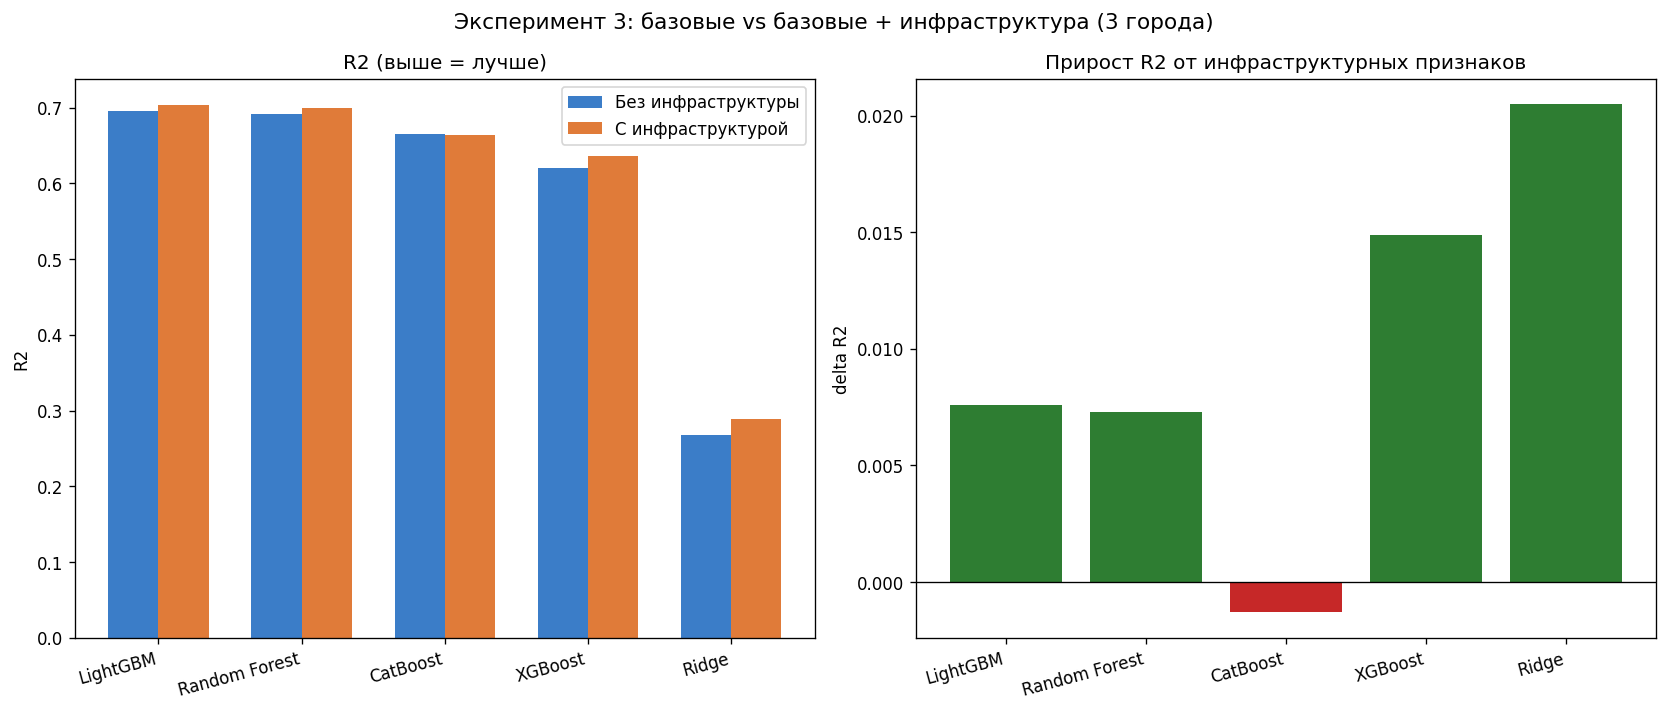

Сохранено: results/figures/exp3_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models_sorted = comparison.index.tolist()
x = np.arange(len(models_sorted))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, comparison['R2 (base)'], w, label='Без инфраструктуры', color='#3B7DC8')
ax.bar(x + w/2, comparison['R2 (infra)'], w, label='С инфраструктурой', color='#E07B39')
ax.set_xticks(x); ax.set_xticklabels(models_sorted, rotation=15, ha='right')
ax.set_ylabel('R2'); ax.set_title('R2 (выше = лучше)'); ax.legend()

ax = axes[1]
delta = comparison['delta_R2']
colors = ['#2e7d32' if v > 0 else '#c62828' for v in delta]
ax.bar(x, delta, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(models_sorted, rotation=15, ha='right')
ax.set_ylabel('delta R2'); ax.set_title('Прирост R2 от инфраструктурных признаков')

plt.suptitle('Эксперимент 3: базовые vs базовые + инфраструктура (3 города)', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/exp3_comparison.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/figures/exp3_comparison.png')

## 5. Важность признаков (LightGBM + инфраструктура)

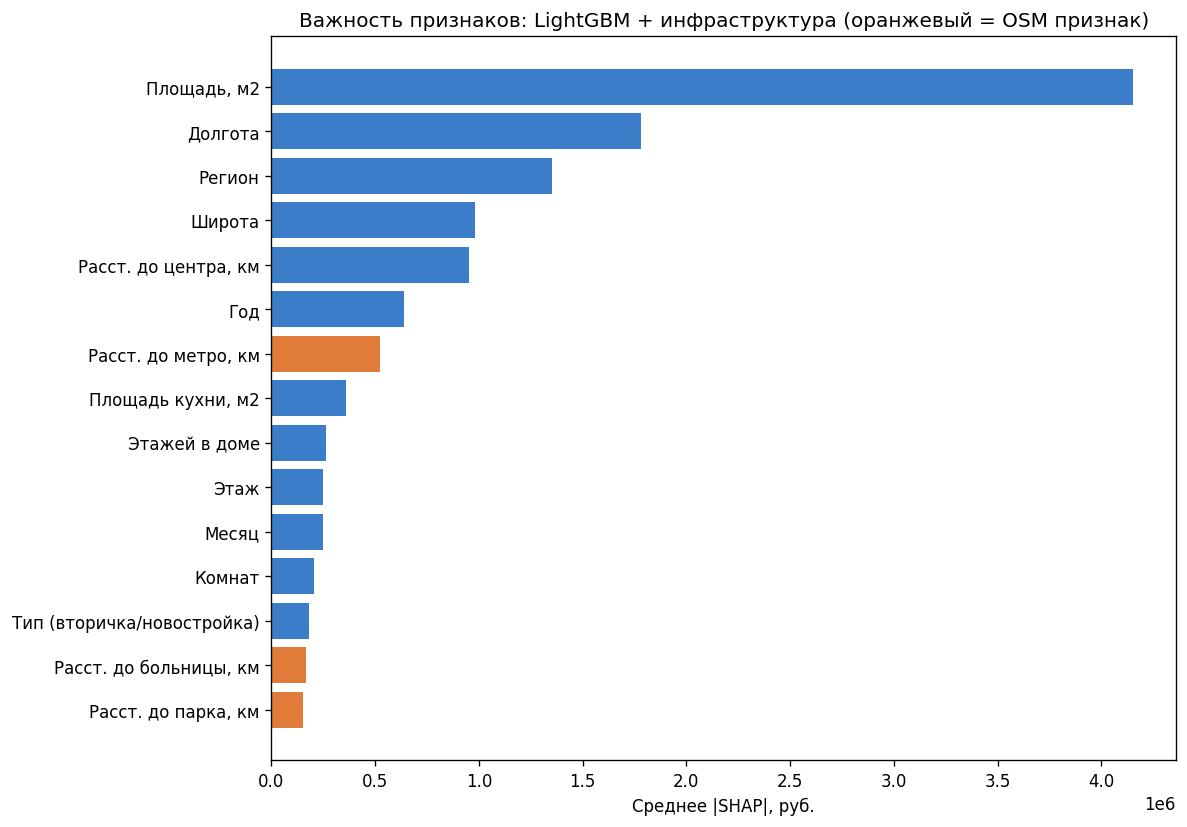

SHAP по инфраструктурным признакам:
  Расст. до метро, км: 0.5236 млн руб.
  Расст. до школы, км: 0.1182 млн руб.
  Расст. до больницы, км: 0.1679 млн руб.
  Расст. до парка, км: 0.1521 млн руб.


In [16]:
import shap

FEATURE_NAMES_RU = {
    'area':          'Площадь, м2',
    'kitchen_area':  'Площадь кухни, м2',
    'level':         'Этаж',
    'levels':        'Этажей в доме',
    'rooms':         'Комнат',
    'object_type':   'Тип (вторичка/новостройка)',
    'region':        'Регион',
    'dist_to_center':'Расст. до центра, км',
    'geo_lat':       'Широта',
    'geo_lon':       'Долгота',
    'year':          'Год',
    'month':         'Месяц',
    'dist_metro':    'Расст. до метро, км',
    'dist_school':   'Расст. до школы, км',
    'dist_hospital': 'Расст. до больницы, км',
    'dist_park':     'Расст. до парка, км',
}
INFRA_SET = {'dist_metro', 'dist_school', 'dist_hospital', 'dist_park'}

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                               num_leaves=127, random_state=SEED, n_jobs=-1, verbose=-1)
lgb_model.fit(X_tr_infra, y_tr)

sample_idx = np.random.choice(len(X_te_infra), size=min(5000, len(X_te_infra)), replace=False)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_te_infra[sample_idx])

mean_shap = np.abs(shap_values).mean(axis=0)
feat_names_ru = [FEATURE_NAMES_RU.get(f, f) for f in FEATURES_INFRA]
infra_ru = {FEATURE_NAMES_RU[f] for f in INFRA_SET}

order = np.argsort(mean_shap)[::-1][:15]
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E07B39' if feat_names_ru[i] in infra_ru else '#3B7DC8' for i in order]
ax.barh([feat_names_ru[i] for i in order[::-1]], mean_shap[order[::-1]],
        color=bar_colors[::-1])
ax.set_xlabel('Среднее |SHAP|, руб.')
ax.set_title('Важность признаков: LightGBM + инфраструктура (оранжевый = OSM признак)')
plt.tight_layout()
plt.savefig('results/figures/exp3_shap_lgbm.png', bbox_inches='tight')
plt.show()

print('SHAP по инфраструктурным признакам:')
for f in FEATURES_INFRA:
    if f in INFRA_SET:
        idx = FEATURES_INFRA.index(f)
        print(f'  {FEATURE_NAMES_RU[f]}: {mean_shap[idx]/1e6:.4f} млн руб.')

## 6. Выводы

**Эксперимент 3** добавляет 4 инфраструктурных признака (расстояние до ближайшей станции метро, школы, больницы, парка) для трёх крупнейших городов.

**Ожидаемые результаты:**
- Расстояние до метро — наиболее важный инфраструктурный признак (особенно для Москвы)
- Прирост R² ожидается 0.01–0.03 у древесных моделей
- Линейная регрессия может улучшиться значительнее

**Ограничения:**
- Эксперимент только на 3 городах (Москва, СПб, Новосибирск)
- OSM данные за 2026 год, тогда как сделки 2018–2021
- Расстояние = прямая линия (haversine), не учитывает реальное время пути